In [62]:
a_s= soup.find_all('a')

In [230]:
import seaborn as sns
import glob
from bs4 import BeautifulSoup
import glob, os 
from tqdm.auto import tqdm
import itertools
import sys
sys.path.insert(0, '../scripts-homepage-data/')
import get_bounding_boxes_from_html as bb
import pandas as pd 
from tqdm.auto import tqdm
import re 

def get_links_from_files(file_list, show_progress=False):
    output_links = []
    file_iter = file_list
    if show_progress:
        file_iter = tqdm(file_list)
    
    for f_name in file_iter:
        with open(f_name) as f:
            wb_key = re.search('\d{14}', f_name)[0]
            soup = BeautifulSoup(f.read(), 'lxml')
            a_s = soup.find_all('a')
            a_s = list(filter(lambda x: x.attrs.get('href') is not None, a_s))
            hrefs = list(map(lambda x: x['href'], a_s))
            output_links += list(map(lambda h: {'href': h, 'wb_key': wb_key}, hrefs))
    return output_links

In [205]:
wayback_scrape_dir = '../data/sfchron-ten-years'
sfchron_files = glob.glob(wayback_scrape_dir + '/web.archive.org/web/*/sfchronicle.com/*')
sfchron_files = sorted(sfchron_files, key=lambda x: x.split('/')[-3])

In [206]:
sfchron_bbs, _ = await bb.get_bounding_boxes_for_files(sfchron_files)

In [220]:
for bb_df in sfchron_bbs:
    if (bb_df is not None) and len(bb_df) > 0:        
        key = bb_df.iloc[0]['key']
        bb_df.to_csv(f'../data/10-years-sfchron-homepage-csvs/homepage-{key}.csv')

In [235]:
sf_grids = []
for bb_df in tqdm(sfchron_bbs):
    if (bb_df is not None) and (len(bb_df) > 0):
        g = bb.get_coarsified_layout_grid(bb_df, use_perc=True, clip_x=True)
        sf_grids.append(g)

  0%|          | 0/2328 [00:00<?, ?it/s]

In [238]:
average_homepage = sum(sf_grids) / len(sf_grids)

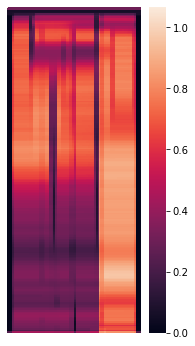

In [243]:
import matplotlib.pyplot as plt 
_, ax = plt.subplots(1, 1, figsize=(3,6))
sns.heatmap(average_homepage, ax=ax)
ax.set_yticks([]); ax.set_xticks([]);

(1248.0, 3727, 1280, 4413)

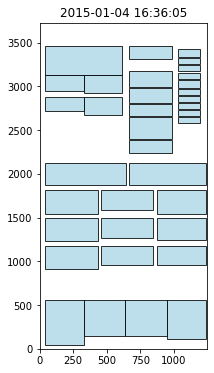

In [250]:
bb.plot_bounding_box_df(sfchron_bbs[600], figsize=(3, 6), clip_right=True)

In [ ]:
all_files = get_links_from_files(sfchron_files, show_progress=True)
all_links = pd.DataFrame(all_files)

In [ ]:
from storysniffer import StorySniffer
sniffer = StorySniffer()

In [148]:
url_list_to_get = (
    all_links['href']
    .value_counts()
    .pipe(lambda s: s / len(sfchron_files))
    .loc[lambda s: s < .15].index
)

In [149]:
article_list = list(filter(sniffer.guess, tqdm(url_list_to_get)))

  0%|          | 0/87899 [00:00<?, ?it/s]

In [175]:
urls_to_get = (
    all_links
    .loc[lambda df: df['href'].isin(article_list)]
    .rename(columns={'wb_key': 'key'})
)

In [182]:
urls_to_get.to_csv('../data/sfchron-article-urls-to-fetch.csv.gzip', index=False, compression='gzip')

In [200]:
from urllib.parse import urlencode, urlparse, urlunparse, parse_qs, urljoin
def clean_url(to_get_url):
    return urljoin(to_get_url, urlparse(to_get_url).path)

urls_to_get= urls_to_get.assign(href=lambda df: df['href'].apply(clean_url))

In [202]:
urls_to_get.drop_duplicates()

,href,key
9,http://www.sfchronicle.com/politics/article/Ju...,20130325002427
13,http://www.sfchronicle.com/education/article/M...,20130325002427
15,http://www.sfchronicle.com/news/article/Introd...,20130325002427
17,http://www.sfchronicle.com/bayarea/place/artic...,20130325002427
19,http://www.sfchronicle.com/bayarea/place/artic...,20130325002427
...,...,...
475291,https://www.sfchronicle.com/file/519/1/5191-Ch...,20200112084303
475292,https://www.sfchronicle.com/file/518/8/5188-Co...,20200112084303
475293,https://www.sfchronicle.com/file/519/0/5190-Sa...,20200112084303
475294,https://www.sfchronicle.com/file/518/9/5189-SF...,20200112084303
